In [ ]:
import sys
print(sys.executable)
import os
from scipy.stats import gaussian_kde

import numpy as np
from scipy.special import erf, erfinv
#from math import erf
from numpy.linalg import norm
from mlmm import VelocityData, plot_learn_curve, n_fold_cv, fileinfo,VelocityDataOmegaData, OmegaData

import matplotlib.pyplot as plt

from datetime import date
today = date.today().strftime("%b-%d-%Y")
import periodictable

import sys
from mlmm import func_postprocess
import time
import pandas as pd

from scipy.stats import norm
from scipy.stats import gaussian_kde

from sklearn.mixture import BayesianGaussianMixture
from sklearn.mixture import GaussianMixture
import joblib

import seaborn as sns
from scipy.stats import gaussian_kde

c:\Users\jespe\miniconda3\python.exe


In [ ]:
def prepare_data_2(path_to_data, path_save_data, system_6D, system_10D, system_omega, wall_temp, Liao_Transfer_Function):
    x_data = []
    y_data = []

    x_omega = []
    y_omega = []

    x_MD = []
    y_MD = []

    for file in os.listdir(path_to_data):

        if file.endswith(".txt") and "MD" in file:
            x_MD.append(os.path.join(path_to_data,file))
            y_MD.append('')

        if file.endswith(".txt") and "omega" in file:
            x_omega.append(os.path.join(path_to_data,file))
            y_omega.append('')
    print("Data files found:",x_MD)


    ######################################################################################
    #------------------------------- Getting translational velocity data
    ####--------------------------------------------------------------------------------------------------
    for x_data_file,y_data_file in zip(x_MD,y_MD):
        

        conf = VelocityData(x_data_file, frames=None)#[0,30000])
        conf.getRep(rep='vxvyvz',nuc=None) #rep options: vxvyvz, vel2norm, vx2,vy2,vz2,vx,vy,vz
        file_name=x_data_file.replace('.','/')
        file_name=file_name.split('/')
        set_name = file_name[1]
        X = conf.X
        y = conf.y
        if "He" in path_to_data:
            mass = getattr(periodictable,'He').mass
            gas_name = 'He'
        elif "Ar" in path_to_data:
            mass = getattr(periodictable,'Ar').mass
            gas_name = 'Ar'
        elif "H2" in path_to_data:
            mass =2* getattr(periodictable,'H').mass
            gas_name = 'H2'
            l_b=0.741e-10
            mass_kg = mass * 0.001 / av_num
            I=(mass_kg/4)*l_b**2
        elif "N2" in path_to_data:
            mass =2* getattr(periodictable,'N').mass
            gas_name = 'N2'
            l_b=1.097e-10
            mass_kg = mass * 0.001 / av_num
            I=(mass_kg/4)*l_b**2
        else:
            print ("Unable to identify impinging atom type...")
            ele = str(input("Enter the impinging atom symbol : "))
            mass = getattr(periodictable,ele).mass
            v_mp = np.sqrt(2 * kB * wall_temp / mass_kg)
            omega_mp = np.sqrt(2 * kB * wall_temp / I)
        print ('Atomic mass for {} molecule is {:1.4f} \n'.format(gas_name,mass))
        n_MD = X.shape[0]
        print('Number of MD tr velocity data points: {} \n'.format(n_MD))
        # Implementing Liao Transfer function on perpendicular velocity component
        v_TF,T_in,T_out,theta_in,theta_out=func_postprocess.liao_transform(X,mass,'y')
        v_RTF=func_postprocess.liao_R_transform(v_TF,theta_in,theta_out,'y')
        MAC_x,MAC_y,MAC_z,EAC_x,EAC_y,EAC_z,EAC_tr=func_postprocess.compute_AC_correlation_method(X,'Ar','y') #
        AC_MD_tr = [MAC_x,MAC_y,MAC_z,EAC_x,EAC_y,EAC_z,EAC_tr]


    ######################################################################################
    #------------------------------- Getting angular velocity data
    ####--------------------------------------------------------------------------------------------------
    if system_omega:
        for x_data_file2,y_data_file2 in zip(x_omega,y_omega):
            #conf2 = OmegaData(x_data_file2, frames=frames)#[0,30000])
            conf2 = OmegaData(x_data_file2, frames=None)#[0,30000])
            conf2.getRep(rep='omega1omega2',nuc=None) #rep options: vxvyvz, vel2norm, vx2,vy2,vz2,vx,vy,vz
            omega_file_name = x_data_file2.replace('.','/')
            omega_file_name = omega_file_name.split('/')
            omega_name = omega_file_name[1]
            print(omega_name)
            X2 = conf2.X2
            y2 = conf2.y2
            print('Number of MD rot velocity data points: {} \n'.format(X2.shape[0]))
            X2_TF=np.copy(X2)
            Y2_TF=np.copy(y2)
            omega_TF=np.vstack((X2_TF,-X2_TF))
            y2_TF=np.hstack((Y2_TF,-Y2_TF))   

    ######################################################################################
    #------------------------------- Implementing GM model on 10D data
    ####--------------------------------------------------------------------------------------------------                   

    if system_10D:
        vel_tr = np.copy(X)
        vel_tr[:,1]=np.abs(vel_tr[:,1])
        vel_tr[:,4]=np.abs(vel_tr[:,4])
        data_for_AC_MD = np.concatenate((vel_tr,X2),axis=1)

        
        if Liao_Transfer_Function:
            #omega_bond = np.copy(X2)
            v_tr=np.copy(v_TF[:n_MD,:])
            v_omega = np.copy(X2)
            v_mp = np.sqrt(2 * kB * wall_temp / mass_kg)
            omega_mp = np.sqrt(2 * kB * wall_temp / I)
            #--- Normalizing the translational and rotational velocities
            data_train_10D = np.concatenate((v_tr*conv_v/v_mp,X2*conv_omega/omega_mp),axis=1)

            print('The total number of training points is: {} \n'.format(data_train_10D.shape[0]))
            
        else:
            data_train_10D = data_for_AC_MD
            print('The total number of training points is: {} \n'.format(data_train_10D.shape[0]))
    
    X_df = pd.DataFrame(data_train_10D, columns=['vx_in', 'vy_in', 'vz_in', 'vx_out', 'vy_out', 'vz_out', 'omega_1_in', 'omega_2_in', 'omega_1_out', 'omega_2_out'], copy=True)
    X_in = np.copy(X[:,:3])
    X_out = np.copy(X[:,3:])

    #X_df = X_df[:8000] # Take small percentage of data for testing # Uncomment if necessary
    
    return X_df

## Functions for training, saving and loading both models

In [ ]:
# N_G as from the literature. TODO: plot N_G vs accomodation coefficient, as is done in the literature
N_G = 600

# Create a function to make and fit a GMM model
def initialize_gmm(X, n_components):
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', tol=0.001)
    gmm.fit(X)
    return gmm

# Create a function to make and fit a Bayesian GMM model
def initialize_bayesian_gmm(X, n_components):
    bayesian_gmm = BayesianGaussianMixture(n_components=n_components)
    bayesian_gmm.fit(X)
    return bayesian_gmm

def save_gmm_model(model: GaussianMixture | BayesianGaussianMixture, filename: str):
    os.makedirs("trained_models", exist_ok=True)  # Ensure the directory exists
    
    with open("trained_models/" + filename, "wb") as f:
        joblib.dump(model, f, protocol=5)

def load_gmm_model(filename: str) -> GaussianMixture | BayesianGaussianMixture:
    with open("trained_models/" + filename, "rb") as f:
        model = joblib.load(f)
    return model


# TODO: lookup how the accomodation coefficient is calculated in the paper and create a for loop to calculate it for all possible models (N_G =1 to 1000)


# Functions for visualization purposes

In [ ]:
from numpy.linalg import norm as linalg_norm
from scipy.stats import norm
from scipy.stats import gaussian_kde

def visualize_pdf_12D(X_df, gmm_model, bayesian_model, title, N_G_gmm, N_G_bayesian):
    """
    Function: visualize_pdf
    Visualizes the probability density function (PDF) of the features in the dataset using both GMM and Bayesian GMM models.
    @param X_df: DataFrame containing the features.
    @param gmm_model: Fitted Gaussian Mixture Model.
    @param bayesian_model: Fitted Bayesian Gaussian Mixture Model.
    @param title (string): Title for the plot.
    """
    
    # Extract marginal pdf for each feature from the GMM model
    fig, ax = plt.subplots(1, 5, figsize=(10, 5))

    labels = ["vx_out", "vy_out", "vz_out", "Omega_1_out", "Omega_2_out"]
    feature_index = [3, 4, 5, 8, 9]
    xlim = np.linspace(-5, 5, 1000)

    for i in range(5):
        pdf_gmm = np.zeros_like(xlim)
        pdf_bayesian = np.zeros_like(xlim)

        for j in range(N_G_gmm):
            # Extract the mean, covariance, and weight for each gmm component
            mean_gmm = gmm_model.means_[j, feature_index[i]]
            cov_gmm = gmm_model.covariances_[j, feature_index[i], feature_index[i]]
            weight_gmm = gmm_model.weights_[j]
            pdf_gmm += weight_gmm * norm.pdf(xlim, loc=mean_gmm, scale=np.sqrt(cov_gmm))
        
        for j in range(N_G_bayesian):   
            # Extract the mean, covariance, and weight for each bayesian component
            mean_bayesian = bayesian_model.means_[j, feature_index[i]]
            cov_bayesian = bayesian_model.covariances_[j, feature_index[i], feature_index[i]]
            weight_bayesian = bayesian_model.weights_[j]
            pdf_bayesian += weight_bayesian * norm.pdf(xlim, loc=mean_bayesian, scale=np.sqrt(cov_bayesian))

            # Compute histogram
            

        # Visualize the pdf of the gmm as a line plot
        ax[i].plot(xlim, pdf_gmm, c='red', alpha=0.8, label='GMM PDF')
        
        # Compute KDE of the actual data
        data_kde = gaussian_kde(X_df.iloc[:, feature_index[i]])
        pdf_data = data_kde(xlim)

        # Plot the data KDE as the empirical PDF
        ax[i].plot(xlim, pdf_data, c='blue', alpha=0.6, label='MD PDF')

        
        # Visualize the pdf of the bayesian model as a line plot
        ax[i].plot(xlim, pdf_bayesian, c='green', alpha=0.8, label='Bayesian PDF')
        ax[i].set_ylim([0, 0.7])
        ax[i].set_xlabel(f'{labels[i]}')
        ax[i].set_title(f'PDF of {labels[i]}')
        
        
    ax[0].set_ylabel("PDF")
    ax[2].legend(loc=1)
    fig.tight_layout()
    plt.show()
    fig.suptitle("pdf " + title, fontsize=16)
    fig.savefig("pdf_" + title, dpi=300, bbox_inches='tight')


In [ ]:
def heatmap_12D(X_df, gmm_model, bayesian_model, title, n_samples=None):
    """
    Function: heatmap_12D
    Visualizes the heatmap of the features in the dataset using both GMM and Bayesian GMM models.
    @param X_df: DataFrame containing the features.
    @param gmm_model: Fitted Gaussian Mixture Model.
    @param bayesian_model: Fitted Bayesian Gaussian Mixture Model.
    @param title (string): Title for the plot.
    """
    if n_samples is None:
        n_samples = X_df.shape[0] # Use the number of rows in X_df if n_samples is not provided

    fntsz = 20
    fig, ax = plt.subplots(5, 3, figsize=(40, 15))
    labels = ["vx_out", "vy_out", "vz_out", "Omega_1_out", "Omega_2_out"]

    # generate samples from the GMM and Bayesian GMM models

    samples_gmm, _ = gmm_model.sample(n_samples)
    samples_bayesian, _ = bayesian_model.sample(n_samples)
    samples_gmm_df = pd.DataFrame(samples_gmm, columns=['vx_in', 'vy_in', 'vz_in', 'vx_out', 'vy_out', 'vz_out', 'omega_1_in', 'omega_2_in', 'omega_1_out', 'omega_2_out'], copy=True)
    samples_bayesian_df = pd.DataFrame(samples_bayesian, columns=['vx_in', 'vy_in', 'vz_in', 'vx_out', 'vy_out', 'vz_out', 'omega_1_in', 'omega_2_in', 'omega_1_out', 'omega_2_out'], copy=True)

    in_index = [0, 1, 2, 6, 7]  # Indices for the input features
    out_index = [3, 4, 5, 8, 9]  # Indices for the output features

    # Loop through the features to create subplots
    for r in range(5):
        # Compute density for MD data
        xy_MD = np.vstack([X_df.iloc[:n_samples, in_index[r]], X_df.iloc[:n_samples, out_index[r]]])
        density_MD = gaussian_kde(xy_MD)(xy_MD)

        # plot the MD data
        ax[r, 0].scatter(X_df.iloc[:n_samples, in_index[r]], X_df.iloc[:n_samples, out_index[r]], c=density_MD, s=15, cmap='jet', alpha=0.6)

        # Compute density for GMM samples
        xy_GMM = np.vstack([samples_gmm_df.iloc[:n_samples, in_index[r]], samples_gmm_df.iloc[:n_samples, out_index[r]]])
        density_GMM = gaussian_kde(xy_GMM)(xy_GMM)

        # plot the GMM data
        ax[r, 1].scatter(samples_gmm_df.iloc[:n_samples, in_index[r]], samples_gmm_df.iloc[:n_samples, out_index[r]], c=density_GMM, s=15, cmap='jet', alpha=0.6)

        # Compute density for Bayesian samples
        xy_Bayesian = np.vstack([samples_bayesian_df.iloc[:n_samples, in_index[r]], samples_bayesian_df.iloc[:n_samples, out_index[r]]])
        density_Bayesian = gaussian_kde(xy_Bayesian)(xy_Bayesian)

        # plot the Bayesian data
        ax[r, 2].scatter(samples_bayesian_df.iloc[:n_samples, in_index[r]], samples_bayesian_df.iloc[:n_samples, out_index[r]], c=density_Bayesian, s=15, cmap='jet', alpha=0.6)

    # row labels
    ax[0, 0].set_ylabel('vx', fontsize=fntsz)
    ax[1, 0].set_ylabel('vy', fontsize=fntsz)
    ax[2, 0].set_ylabel('vz', fontsize=fntsz)
    ax[3, 0].set_ylabel('Omega_1', fontsize=fntsz)
    ax[4, 0].set_ylabel('Omega_2', fontsize=fntsz)
    # column labels
    ax[0, 0].set_title("MD", fontsize=fntsz)
    ax[0, 1].set_title("GMM", fontsize=fntsz)
    ax[0, 2].set_title("Bayesian GMM", fontsize=fntsz)

    fig.suptitle("heatmap "+ title, fontsize=24)
    fig.tight_layout()
    fig.savefig("heatmap_"+ title + '.png', dpi=300, bbox_inches='tight')

# Prepare the DF's

In [ ]:
er_type = 'MAE'

system_6D = False 
system_10D = True # Assignment B uses 10D data since we now take rotational velocity data into account
system_omega = True # Set to false, since we are not using angular velocity data in this assignment
Liao_Transfer_Function = True

kB,conv_v,conv_omega,av_num = 1.38064852e-23,1.0e2,1.0e12,6.022e23

In [ ]:
# prepare the X_df's.

"""
H2_Vel_MD_Sw_0_B300_Th_300.txt and H2_Omega_MD_Sw_0_B300_Th_300.txt
Bottom wall temperature = 300 K
Top wall temperature = 300 K
"""
path_to_data = 'Data_H2_assignment_bayesian_B_1'
path_save_data='./'+path_to_data
wall_temp = 300 # Wall temperature in Kelvin
X_df_1_B = prepare_data_2(path_to_data, path_save_data, system_6D, system_10D, system_omega, wall_temp, Liao_Transfer_Function)
X_df_B = X_df_1_B # For if I want to use the first dataframe only, for testing purposes.
X_df_B.head()


"""
H2_Vel_MD_Sw_0_B300_Th_500.txt and H2_Omega_MD_Sw_0_B300_Th_500.txt
Bottom wall temperature = 300 K
Top wall temperature = 500 K
"""
path_to_data = 'Data_H2_assignment_bayesian_B_2'
path_save_data='./'+path_to_data
wall_temp = 300 # Wall temperature in Kelvin
X_df_2_B = prepare_data_2(path_to_data, path_save_data, system_6D, system_10D, system_omega, wall_temp, Liao_Transfer_Function)


"""
H2_Vel_MD_Sw_0_B300_Th_500.txt and H2_Omega_MD_Sw_0_B300_Th_500.txt
Bottom wall temperature = 300 K
"""
path_to_data = 'Data_H2_assignment_bayesian_B_3'
path_save_data='./'+path_to_data
wall_temp = 300 # Wall temperature in Kelvin
X_df_3_B = prepare_data_2(path_to_data, path_save_data, system_6D, system_10D, system_omega, wall_temp, Liao_Transfer_Function)


## Training and visualizing for "H2_Vel_MD_Sw_0_B300_Th_300" adn "H2_omega_Sw_0_B300_Th_300"

In [ ]:
# Train the gaussian mixture model and bayesian gaussian mixture model on the following data sets:

title1_B = "H2_Sw_0_B300_Th_300 (not converted back from normalized to original units)"
N_G_gmm = 600  # Number of components for GMM
N_G_bayesian = 400  # Number of components for Bayesian GMM

gmm_model_1_B = initialize_gmm(X_df_1_B, N_G_gmm)
save_gmm_model(gmm_model_1_B, f'gmm_model_{title1_B}.pkl')
bayesian_model_1_B = initialize_bayesian_gmm(X_df_1_B, N_G_bayesian)
save_gmm_model(bayesian_model_1_B, f'bayesian_model_{title1_B}.pkl')


c:\Users\20193567\AppData\Local\miniconda3\envs\tensorflow_env\lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


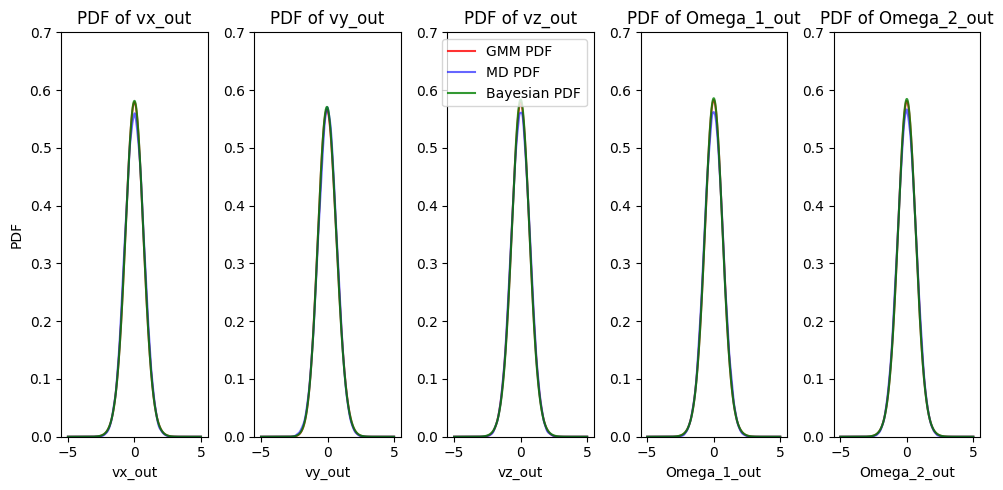

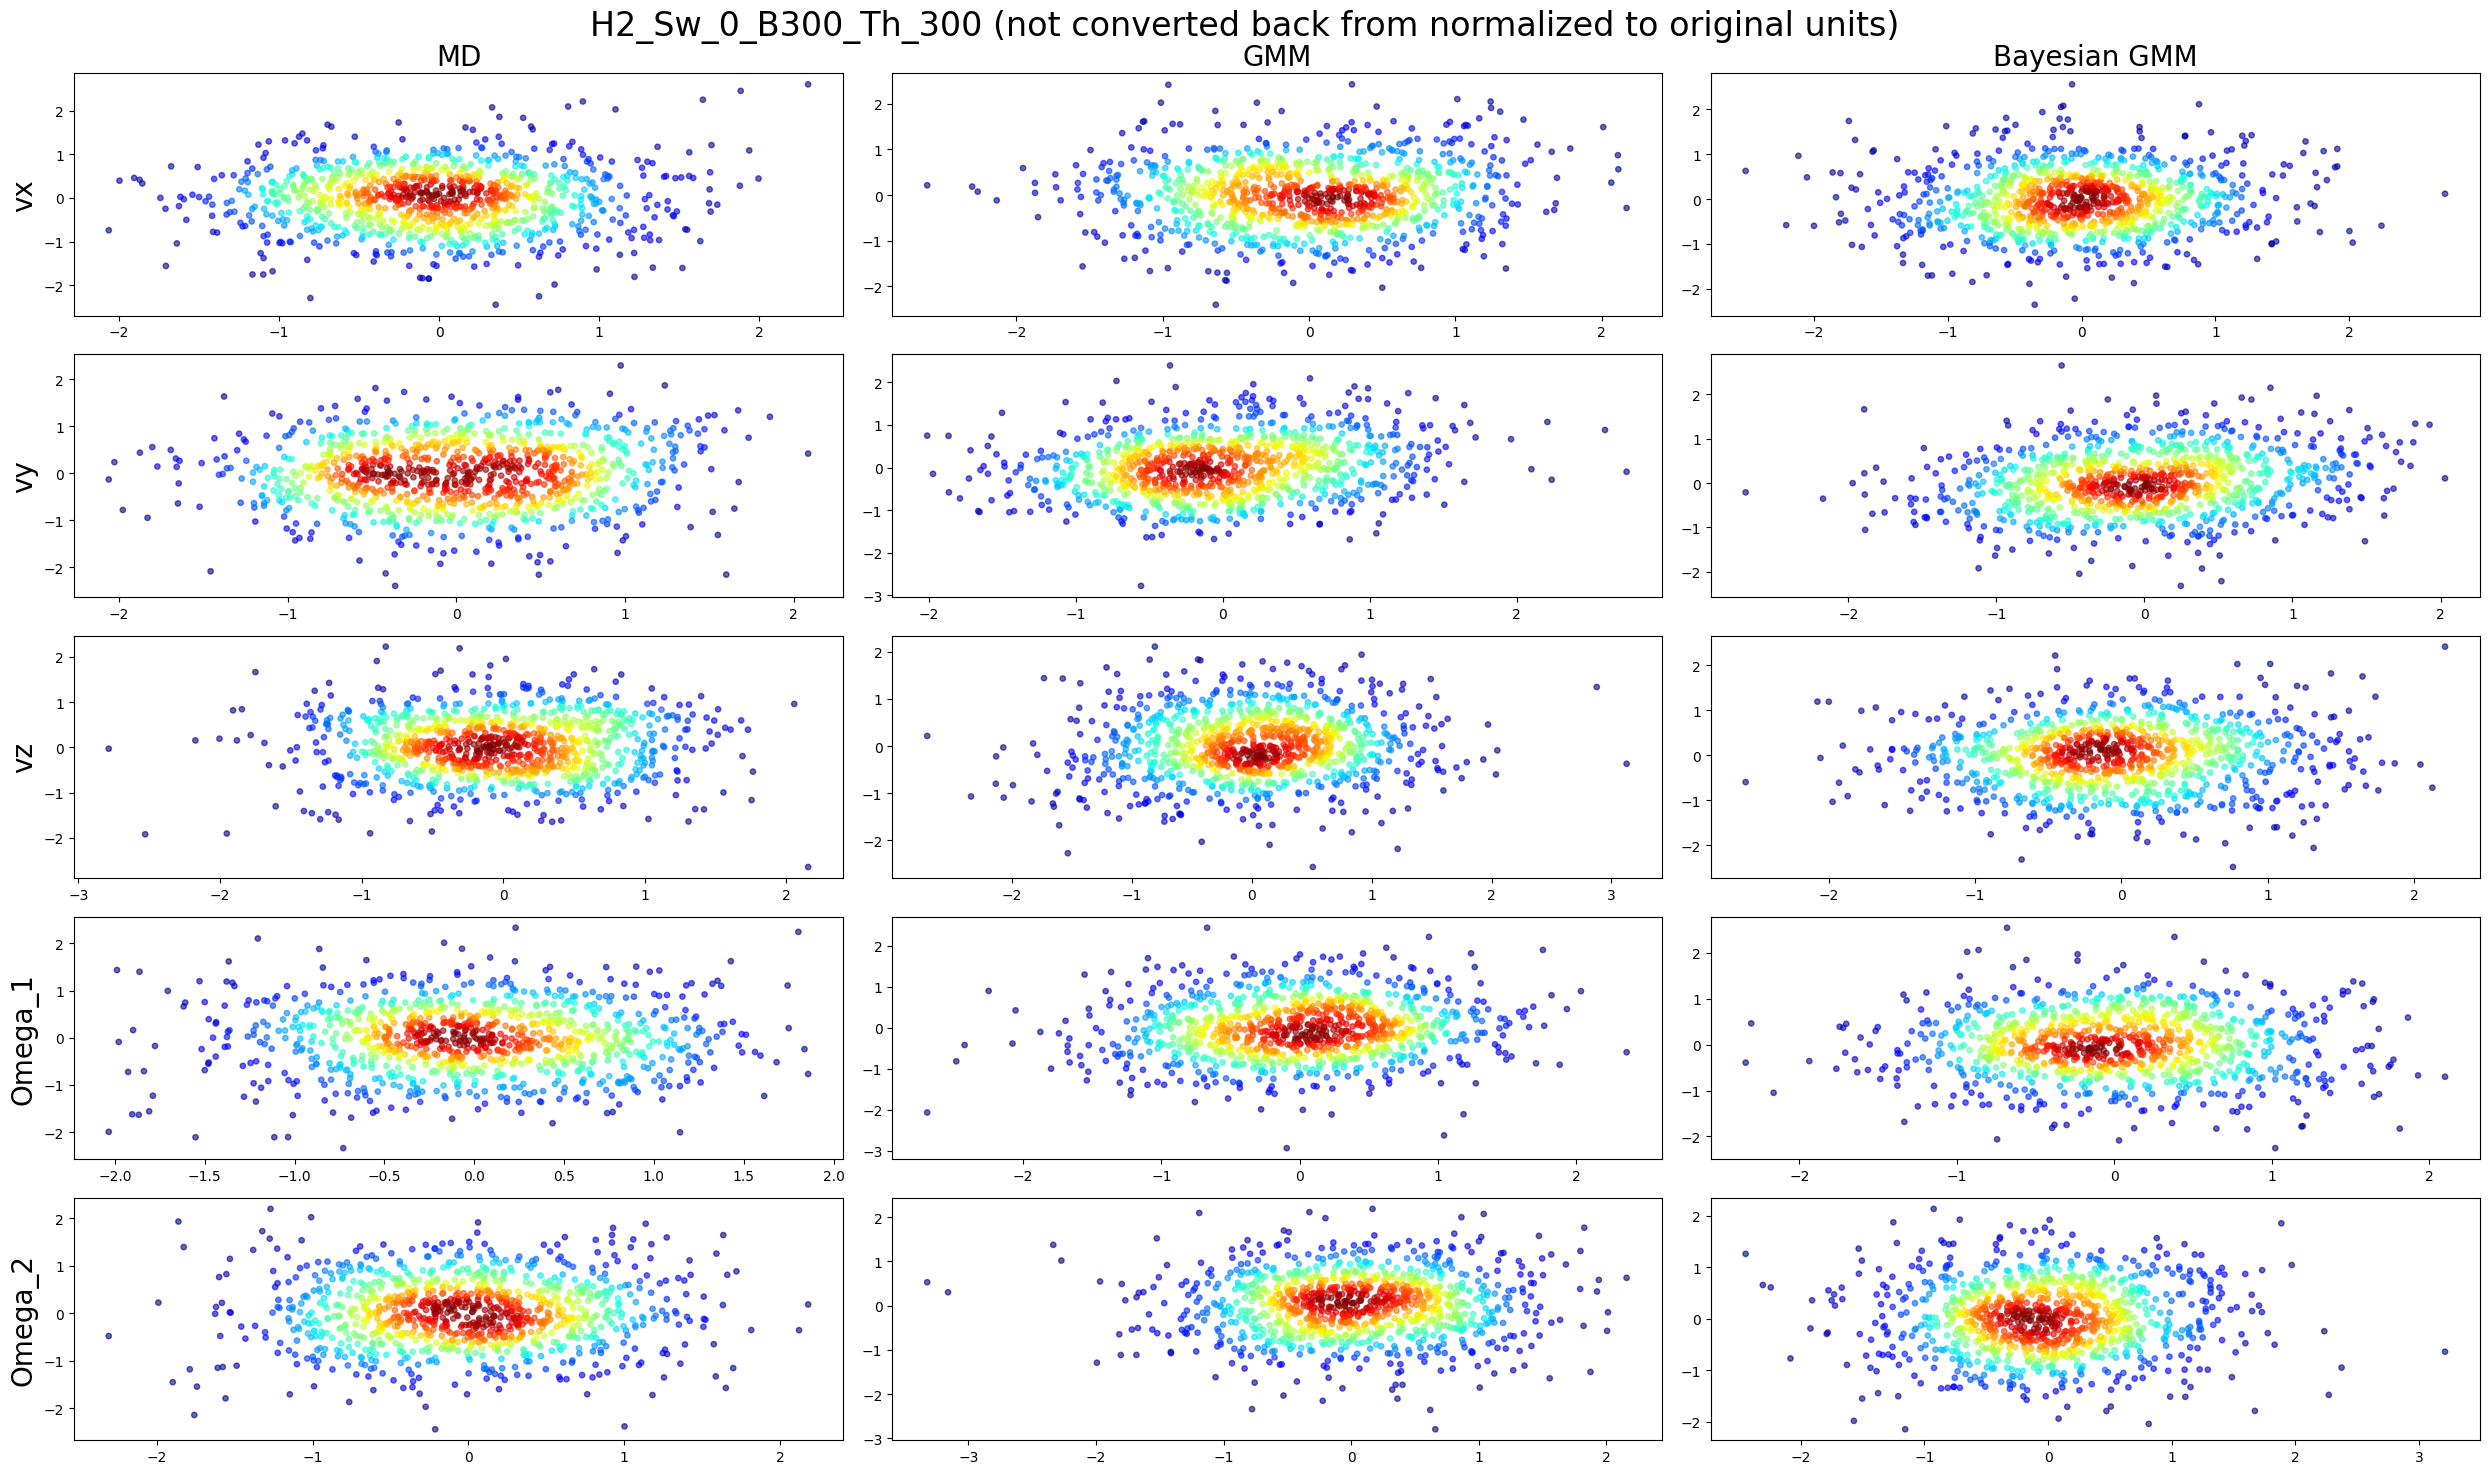

In [ ]:
title1_B = "H2_Sw_0_B300_Th_300 (not converted back from normalized to original units)"
gmm_model_1_B = load_gmm_model(f'gmm_model_{title1_B}.pkl')
bayesian_model_1_B = load_gmm_model(f'bayesian_model_{title1_B}.pkl')

# Seperate the visualization and training part
visualize_pdf_12D(X_df_1_B, gmm_model_1_B, bayesian_model_1_B, title1_B, N_G_gmm, N_G_bayesian)
# Plot heatmap of the GMM
heatmap_12D(X_df_1_B, gmm_model_1_B, bayesian_model_1_B, title1_B, n_samples=X_df_1_B.shape[0])

## Training and visualizing for "H2_Vel_MD_Sw_0_B300_Th_500" adn "H2_omega_Sw_0_B300_Th_500"

In [ ]:
# Train the gaussian mixture model and bayesian gaussian mixture model on the following data sets:

title2_B = "H2_Sw_0_B300_Th_500 (not converted back from normalized to original units)"
N_G_gmm = 600  # Number of components for GMM
N_G_bayesian = 400  # Number of components for Bayesian GMM

gmm_model_2_B = initialize_gmm(X_df_2_B, N_G_gmm)
save_gmm_model(gmm_model_2_B, f'gmm_model_{title2_B}.pkl')
bayesian_model_2_B = initialize_bayesian_gmm(X_df_2_B, N_G_bayesian)
save_gmm_model(bayesian_model_2_B, f'bayesian_model_{title2_B}.pkl')


c:\Users\jespe\miniconda3\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [ ]:
title2_B = "H2_Sw_0_B300_Th_500 (not converted back from normalized to original units)"
gmm_model_2_B = load_gmm_model(f'gmm_model_{title2_B}.pkl')
bayesian_model_2_B = load_gmm_model(f'bayesian_model_{title2_B}.pkl')

# Seperate the visualization and training part
visualize_pdf_12D(X_df_2_B, gmm_model_2_B, bayesian_model_2_B, title2_B, N_G_gmm, N_G_bayesian)

# Plot heatmap of the GMM
heatmap_12D(X_df_2_B, gmm_model_2_B, bayesian_model_2_B, title2_B, n_samples=X_df_2_B.shape[0])

## Training and visualizing for "H2_Vel_MD_Sw_0_T500_Tb_300" adn "H2_omega_Sw_0_T500_Tb_300"

In [ ]:
# Train the gaussian mixture model and bayesian gaussian mixture model on the following data sets:

title3_B = "H2_Vel_MD_Sw_0_T500_Tb_300 (not converted back from normalized to original units)"
N_G_gmm = 600  # Number of components for GMM
N_G_bayesian = 400  # Number of components for Bayesian GMM

gmm_model_3_B = initialize_gmm(X_df_3_B, N_G_gmm)
save_gmm_model(gmm_model_3_B, f'gmm_model_{title3_B}.pkl')
bayesian_model_3_B = initialize_bayesian_gmm(X_df_3_B, N_G_bayesian)
save_gmm_model(bayesian_model_3_B, f'bayesian_model_{title3_B}.pkl')


In [ ]:
title3_B = "H2_Vel_MD_Sw_0_T500_Tb_300 (not converted back from normalized to original units)"
gmm_model_3_B = load_gmm_model(f'gmm_model_{title3_B}.pkl')
bayesian_model_3_B = load_gmm_model(f'bayesian_model_{title3_B}.pkl')

# Seperate the visualization and training part
visualize_pdf_12D(X_df_3_B, gmm_model_3_B, bayesian_model_3_B, title3_B, N_G_gmm, N_G_bayesian)

# Plot heatmap of the GMM
heatmap_12D(X_df_3_B, gmm_model_3_B, bayesian_model_3_B, title3_B, n_samples=X_df_3_B.shape[0])